In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, r2_score

from sklearn.preprocessing import StandardScaler

import joblib

sns.set_theme(style="darkgrid")
plt.rcParams["figure.dpi"] = 100

CLEAN_PATH   = "../data/cleaned/"
FIGURES_PATH = "../outputs/figures/"
MODELS_PATH  = "../outputs/models/"

os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)

print("Libraries imported!")

Libraries imported!


In [2]:
co2_emissions = pd.read_csv(CLEAN_PATH + "co2_emissions_clean.csv")
energy_mix    = pd.read_csv(CLEAN_PATH + "energy_mix_clean.csv")
temp_anomaly  = pd.read_csv(CLEAN_PATH + "temp_anomaly_clean.csv")

print("Datasets loaded!")
print(f"co2_emissions : {co2_emissions.shape[0]:,} rows")
print(f"energy_mix    : {energy_mix.shape[0]:,} rows")
print(f"temp_anomaly  : {temp_anomaly.shape[0]:,} rows")

Datasets loaded!
co2_emissions : 1,350 rows
energy_mix    : 1,350 rows
temp_anomaly  : 2,528 rows


In [3]:
# Preparing Data for ML

# PREDICT co2_emissions_mt

# INPUT  → year, population, energy mix percentages, temperature
# OUTPUT → co2 emissions amount

# Getting yearly global temperature average
global_temp_yearly = (
    temp_anomaly[temp_anomaly["region"] == "Global"]
    .groupby("year")["temp_anomaly_c"]
    .mean()
    .reset_index()
    .rename(columns={"temp_anomaly_c": "avg_temp_anomaly"})
)

# Merging co2_emissions with energy_mix
df = pd.merge(
    co2_emissions,
    energy_mix[["year", "country", "coal_pct", "renewables_total_pct",
                "fossil_total_pct", "solar_pct", "wind_pct"]],
    on=["year", "country"],
    how="inner"
)

# Merging with temperature
df = pd.merge(df, global_temp_yearly, on="year", how="left")

print("Data merged successfully!")
print(f"Combined dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumns available: {list(df.columns)}")

Data merged successfully!
Combined dataset: 1,350 rows, 14 columns

Columns available: ['year', 'country', 'iso3', 'region', 'co2_emissions_mt', 'population_millions', 'co2_per_capita_t', 'co2_intensity_kg_per_gdp_usd', 'coal_pct', 'renewables_total_pct', 'fossil_total_pct', 'solar_pct', 'wind_pct', 'avg_temp_anomaly']


In [4]:
# Selecting Features and Target


features = [
    "year",                  
    "population_millions",   # larger population = more emissions
    "coal_pct",              # more coal = more emissions
    "renewables_total_pct",  # more renewables = less emissions
    "fossil_total_pct",      
    "solar_pct",             # solar energy share
    "wind_pct",              # wind energy share
    "avg_temp_anomaly"       
]

target = "co2_emissions_mt"  


df_ml = df[features + [target]].dropna()

print(f"Dataset ready for ML!")
print(f"   Total rows    : {df_ml.shape[0]:,}")
print(f"   Features used : {len(features)}")
print(f"   Target        : {target}")
print(f"\nFirst 5 rows:")
print(df_ml.head())

Dataset ready for ML!
   Total rows    : 1,350
   Features used : 8
   Target        : co2_emissions_mt

First 5 rows:
   year  population_millions  coal_pct  renewables_total_pct  \
0  2000                 38.2      1.23                  4.64   
1  2001                 38.6      0.93                  5.52   
2  2002                 38.9      1.40                  7.09   
3  2003                 39.2      0.37                  4.18   
4  2004                 39.5      0.75                  2.76   

   fossil_total_pct  solar_pct  wind_pct  avg_temp_anomaly  co2_emissions_mt  
0             93.21       0.00      0.42          0.448500             102.0  
1             92.87       1.62      0.79          0.511250             103.0  
2             92.08       0.52      1.87          0.613250             105.4  
3             94.19       2.44      0.36          0.651667             108.1  
4             96.55       1.07      0.56          0.555917             111.1  


In [5]:
#Spliting Data

# We split our data into two parts:

X = df_ml[features]   # all input columns
y = df_ml[target]     # the column to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      
    random_state=42     
)

print("Data split complete!")
print(f"   Training rows : {X_train.shape[0]:,}")
print(f"   Testing rows  : {X_test.shape[0]:,}")

Data split complete!
   Training rows : 1,080
   Testing rows  : 270


In [6]:
#Scale Features

scaler = StandardScaler()

# Fit the scaler on training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Only transform the test data
X_test_scaled = scaler.transform(X_test)

print("Features scaled!")
print("   All features are now on the same scale")

Features scaled!
   All features are now on the same scale


In [7]:
# Trainning Linear Regression Model

# Linear Regression draws the best straight line

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
lr_predictions = lr_model.predict(X_test_scaled)

# Measuring how good the predictions are
lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_r2  = r2_score(y_test, lr_predictions)

print("Linear Regression trained!")
print(f"   Mean Absolute Error : {lr_mae:,.0f} Million Tonnes")
print(f"   R² Score            : {lr_r2:.4f}")
print(f"\n R² Score explanation:")
print(f"   {lr_r2:.2%} of the variation in CO2 emissions is explained by our model")

Linear Regression trained!
   Mean Absolute Error : 449 Million Tonnes
   R² Score            : 0.6130

 R² Score explanation:
   61.30% of the variation in CO2 emissions is explained by our model


In [8]:
# Training Random Forest Model

# Random Forest builds many decision trees
# and combines their predictions


rf_model = RandomForestRegressor(
    n_estimators=100,   # number of trees in the forest
    random_state=42     
)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
rf_predictions = rf_model.predict(X_test_scaled)

# Measure performance
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2  = r2_score(y_test, rf_predictions)

print("Random Forest trained!")
print(f"   Mean Absolute Error : {rf_mae:,.0f} Million Tonnes")
print(f"   R² Score            : {rf_r2:.4f}")
print(f"\n R² Score explanation:")
print(f"   {rf_r2:.2%} of the variation in CO2 emissions is explained by our model")

Random Forest trained!
   Mean Absolute Error : 63 Million Tonnes
   R² Score            : 0.9737

 R² Score explanation:
   97.37% of the variation in CO2 emissions is explained by our model


In [9]:

# Comparing Both Models

print("=" * 50)
print("        MODEL COMPARISON")
print("=" * 50)
print(f"{'Model':<25} {'MAE':>12} {'R² Score':>12}")
print("-" * 50)
print(f"{'Linear Regression':<25} {lr_mae:>12,.0f} {lr_r2:>12.4f}")
print(f"{'Random Forest':<25} {rf_mae:>12,.0f} {rf_r2:>12.4f}")
print("=" * 50)

# Pick the best model
if rf_r2 > lr_r2:
    print("\n Random Forest is the better model!")
    best_model = rf_model
    best_predictions = rf_predictions
else:
    print("\n Linear Regression is the better model!")
    best_model = lr_model
    best_predictions = lr_predictions

        MODEL COMPARISON
Model                              MAE     R² Score
--------------------------------------------------
Linear Regression                  449       0.6130
Random Forest                       63       0.9737

 Random Forest is the better model!


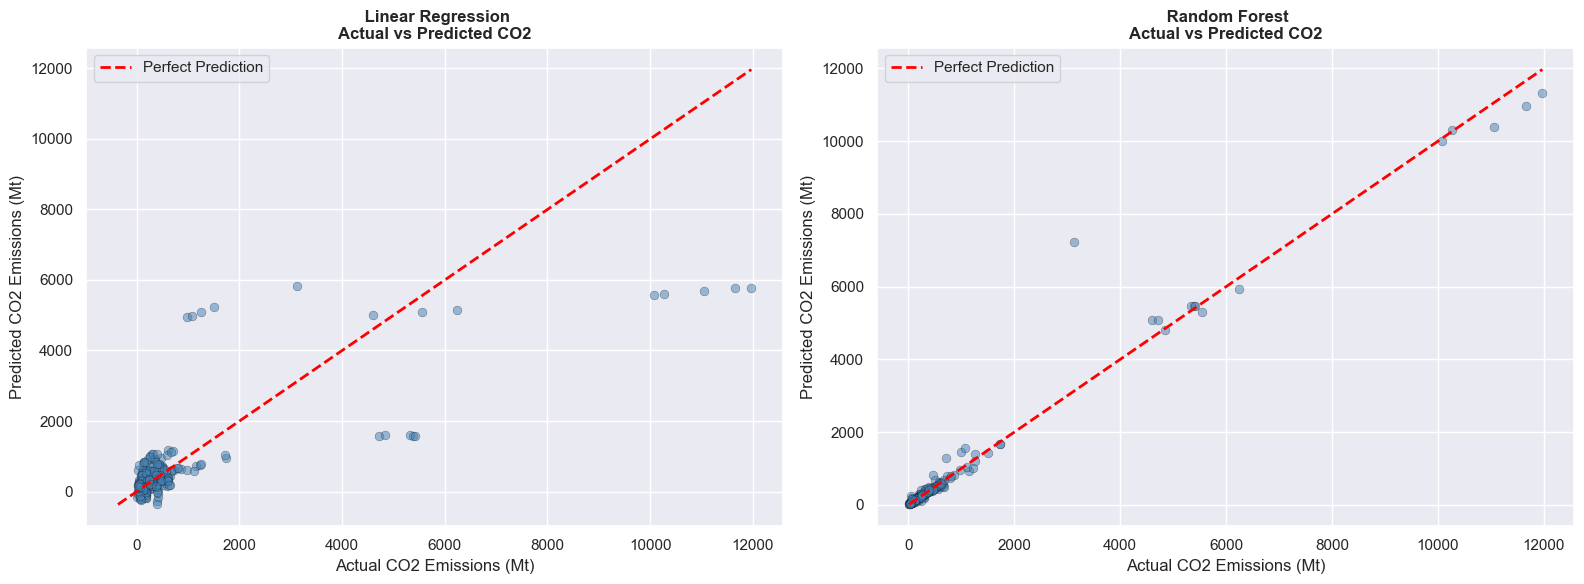

Chart 1 saved!


In [10]:
# Actual vs Predicted Chart


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, predictions, title in zip(
    axes,
    [lr_predictions, rf_predictions],
    ["Linear Regression", "Random Forest"]
):
    ax.scatter(
        y_test,
        predictions,
        alpha=0.5,
        color="steelblue",
        edgecolors="black",
        linewidth=0.3,
        s=40
    )

    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="red",
        linewidth=2,
        linestyle="--",
        label="Perfect Prediction"
    )

    ax.set_title(f" {title}\nActual vs Predicted CO2", fontweight="bold")
    ax.set_xlabel("Actual CO2 Emissions (Mt)")
    ax.set_ylabel("Predicted CO2 Emissions (Mt)")
    ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + "11_actual_vs_predicted.png", dpi=150)
plt.show()
print("Chart 1 saved!")

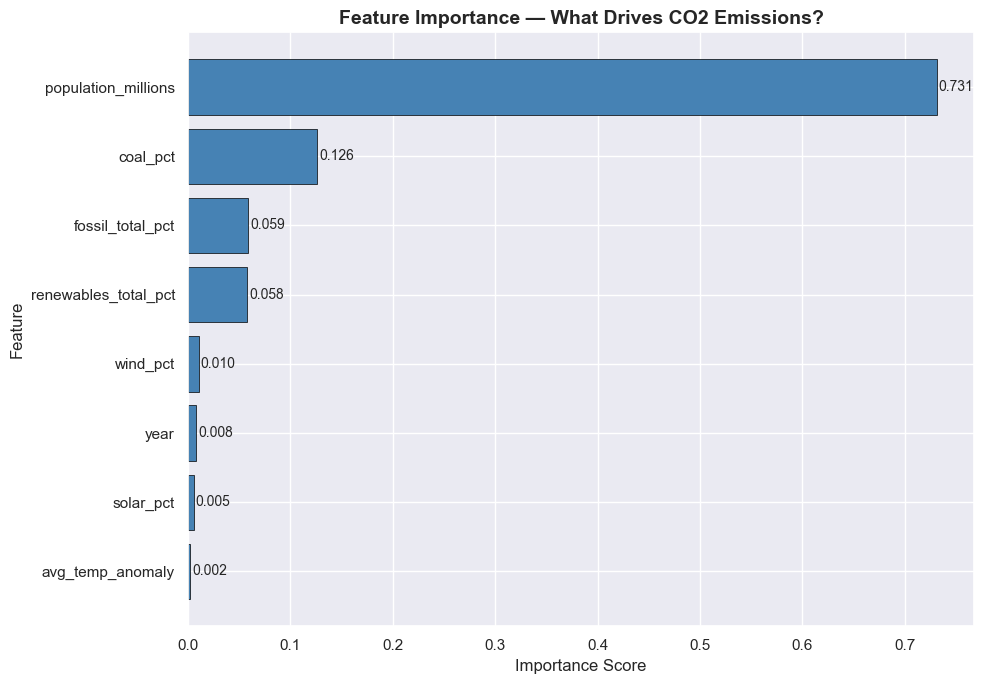

Chart 2 saved!


In [11]:
# Feature Importance Chart

# This shows which input features matter most

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    "Feature"   : features,
    "Importance": importances
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    feature_importance_df["Feature"],
    feature_importance_df["Importance"],
    color="steelblue",
    edgecolor="black",
    linewidth=0.5
)

# Add value labels on each bar
for bar, val in zip(bars, feature_importance_df["Importance"]):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        fontsize=10
    )

ax.set_title("Feature Importance — What Drives CO2 Emissions?",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score", fontsize=12)
ax.set_ylabel("Feature", fontsize=12)

plt.tight_layout()
plt.savefig(FIGURES_PATH + "12_feature_importance.png", dpi=150)
plt.show()
print("Chart 2 saved!")

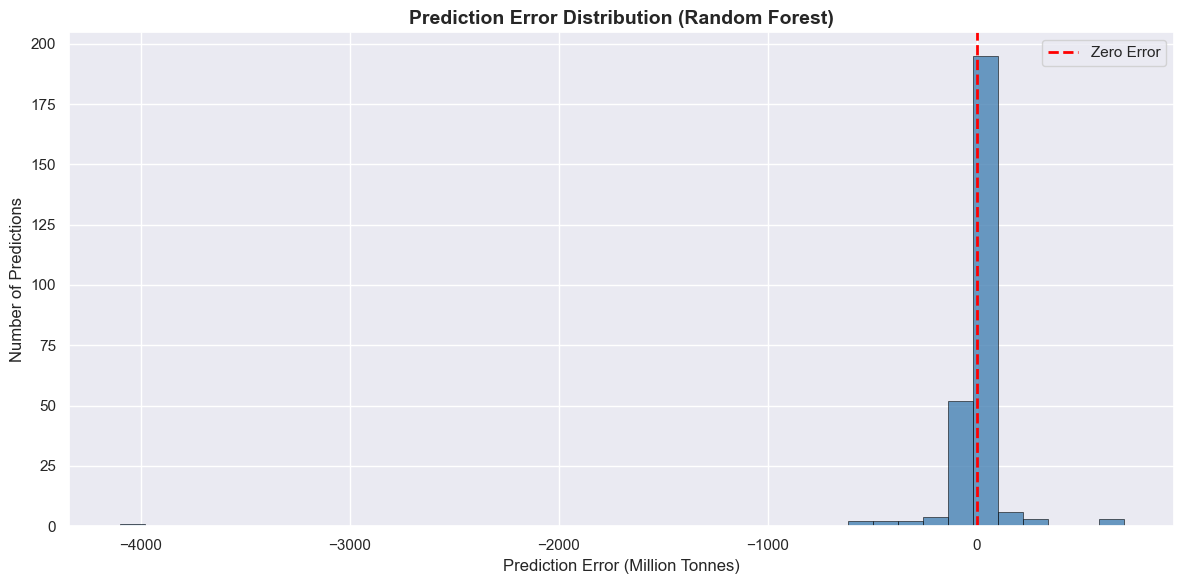

Chart 3 saved!


In [12]:
# Prediction Error Distribution

# This shows how big our prediction errors are

errors = y_test.values - rf_predictions

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    errors,
    bins=40,
    color="steelblue",
    edgecolor="black",
    linewidth=0.5,
    alpha=0.8
)

# Mark zero error line
ax.axvline(0, color="red", linewidth=2, linestyle="--", label="Zero Error")

ax.set_title("Prediction Error Distribution (Random Forest)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Prediction Error (Million Tonnes)", fontsize=12)
ax.set_ylabel("Number of Predictions", fontsize=12)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_PATH + "13_error_distribution.png", dpi=150)
plt.show()
print("Chart 3 saved!")

In [13]:
# Saving the trained model to a file


joblib.dump(best_model, MODELS_PATH + "co2_prediction_model.pkl")
joblib.dump(scaler, MODELS_PATH + "co2_scaler.pkl")

print("Model saved to outputs/models/")
print("   co2_prediction_model.pkl — the trained model")
print("   scaler.pkl               — the data scaler")
print("\n These files can be loaded later to make new predictions")
print("   without retraining the model from scratch")

Model saved to outputs/models/
   co2_prediction_model.pkl — the trained model
   scaler.pkl               — the data scaler

 These files can be loaded later to make new predictions
   without retraining the model from scratch


In [14]:
# Sample Prediction

# Using our model to predict CO2 emissions for a hypothetical country scenario


print("   Sample Prediction — What would CO2 emissions be for:")
print("   Year: 2025")
print("   Population: 500 million")
print("   Coal usage: 20%")
print("   Renewables: 40%")
print("   Fossil fuels: 55%")
print("   Solar: 10%")
print("   Wind: 15%")
print("   Temperature anomaly: 1.2°C")
print()

# Create a sample input
sample = pd.DataFrame([{
    "year"                : 2025,
    "population_millions" : 500,
    "coal_pct"            : 20,
    "renewables_total_pct": 40,
    "fossil_total_pct"    : 55,
    "solar_pct"           : 10,
    "wind_pct"            : 15,
    "avg_temp_anomaly"    : 1.2
}])

# Scale the sample using our saved scaler
sample_scaled = scaler.transform(sample)

# Make prediction
prediction = best_model.predict(sample_scaled)[0]

print(f" Predicted CO2 Emissions: {prediction:,.0f} Million Tonnes")

   Sample Prediction — What would CO2 emissions be for:
   Year: 2025
   Population: 500 million
   Coal usage: 20%
   Renewables: 40%
   Fossil fuels: 55%
   Solar: 10%
   Wind: 15%
   Temperature anomaly: 1.2°C

 Predicted CO2 Emissions: 6,706 Million Tonnes
